# `center_momentum`이 너무 크면 무슨 일이 생기나

DINO 교사 분포는 centering + sharpening 두 단계다.

$$
P_t(k) = \frac{\exp\big((z_t(k) - c_k)/\tau_t\big)}{\sum_j \exp\big((z_t(j) - c_j)/\tau_t\big)},
\qquad \tau_t = 0.04
$$

그리고 `center`는 교사 출력 배치 평균의 EMA다 (`DINOLoss.update_center`).

$$
c \leftarrow m_c\, c + (1-m_c)\,\frac{1}{BW}\sum_i z_t(i), \qquad m_c = 0.9\ \text{(기본값)}
$$

이 노트북에서 확인할 것:

1. EMA의 흡수 지연은 $\approx 1/(1-m_c)$ step, 잔여 편향은 $m_c^{\,t}\delta$ 다.
2. 지연 동안 $\tau_t=0.04$ 의 sharpening이 잔여 편향을 25배로 증폭해 **단일 프로토타입 붕괴**를 만든다.
3. 반대로 $m_c$ 가 너무 작으면 center가 배치 잡음을 물고 흔들린다 → **bias/variance 트레이드오프**.

In [1]:
# 필요 패키지: numpy, plotly, kaleido  (torch 불필요 — softmax는 numpy로 직접 계산)
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:  # VSCode 셀/Jupyter에서만 렌더링
            fig.show()
    except ImportError:
        pass


def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)


K = 256          # 프로토타입 수 (실제 DINO는 65536)
B = 64           # 배치 (× world_size)
SIGMA = 0.5      # 교사 logit 표준편차
TAU_T = 0.04     # teacher_temp
STEPS = 800
ONSET = 200      # 구조적 편향이 나타나는 step
NBIAS = 4        # 편향을 받는 차원 수
BIAS = 2.0       # 편향 크기 (logit 단위)
MS = [0.5, 0.9, 0.99, 0.999]

print(f"K={K}  B={B}  tau_t={TAU_T}  log K = {np.log(K):.3f} nats")
print(f"편향: step {ONSET}부터 차원 0..{NBIAS-1} 의 logit에 +{BIAS}")
print(f"sharpening 증폭 배율 1/tau_t = {1/TAU_T:.0f}배")

K=256  B=64  tau_t=0.04  log K = 5.545 nats
편향: step 200부터 차원 0..3 의 logit에 +2.0
sharpening 증폭 배율 1/tau_t = 25배


## 1. EMA 계단 응답 — 순수 산수

배치 평균이 $\delta$ 만큼 계단식으로 튀면

$$
c(t) = (1 - m_c^{\,t})\,\delta, \qquad \text{잔여 편향} = m_c^{\,t}\,\delta
$$

시간상수 $\tau \approx 1/(1-m_c)$, 90% 흡수까지 $t_{90} = \ln 0.1 / \ln m_c$.

In [2]:
print(f"{'m_c':>7} {'1/(1-m)':>9} {'t90':>7} {'10 step 뒤 잔여':>15}")
for m in MS:
    t90 = np.log(0.1) / np.log(m)
    print(f"{m:>7} {1/(1-m):>9.1f} {t90:>7.1f} {m**10:>14.1%}")

    m_c   1/(1-m)     t90    10 step 뒤 잔여
    0.5       2.0     3.3           0.1%
    0.9      10.0    21.9          34.9%
   0.99     100.0   229.1          90.4%
  0.999    1000.0  2301.4          99.0%


`m_c = 0.999`면 center는 사실상 **1000 step 전의 배치 평균**을 들고 있다.
그동안 centering은 켜져 있으나 아무 일도 하지 않는다.

## 2. 장난감 DINO 교사 출력 스트림

매 step 교사 logit을 $z_t \sim \mathcal{N}(\text{bias}, \sigma^2)$ 로 뽑는다.
`ONSET` 이후 4개 차원에만 `+BIAS` 를 얹어 **구조적 편향**(입력과 무관하게 항상 유리한 프로토타입)을 만든다.

각 $m_c$ 에 대해 추적할 것:
- `c[0]` : center가 편향을 얼마나 흡수했나 (목표 = 2.0)
- 편향 4차원이 차지하는 softmax 확률 질량 (uniform 기대값 = $4/256 = 1.56\%$)
- 교사 엔트로피 $H(P_t)$
- argmax가 편향 차원에 떨어지는 비율

In [3]:
def simulate(m_c, steps=STEPS, onset=ONSET, seed=0):
    rng = np.random.default_rng(seed)
    bias = np.zeros(K)
    bias[:NBIAS] = BIAS
    center = np.zeros(K)
    h = {"c0": [], "mass": [], "ent": [], "argmax": [], "cnorm": []}
    for s in range(steps):
        b = bias if s >= onset else 0.0
        zt = rng.normal(0.0, SIGMA, size=(B, K)) + b      # 교사 출력 (2B행 대신 B행)
        p = softmax((zt - center) / TAU_T, axis=-1)       # centering + sharpening
        h["c0"].append(center[:NBIAS].mean())
        h["mass"].append(p[:, :NBIAS].sum(-1).mean())
        h["ent"].append(float(-(p * np.log(np.clip(p, 1e-12, None))).sum(-1).mean()))
        h["argmax"].append(float((p.argmax(-1) < NBIAS).mean()))
        h["cnorm"].append(float(np.linalg.norm(center)))
        # EMA 갱신 (update_center 와 동일)
        center = m_c * center + (1 - m_c) * zt.mean(0)
    return {k: np.asarray(v) for k, v in h.items()}


runs = {m: simulate(m) for m in MS}

UNIFORM = NBIAS / K
# 개별 step의 질량은 표집 잡음이 크므로(sharp softmax → 사실상 argmax 세기) 구간 평균으로 본다.
print(f"uniform 기대 질량 = {UNIFORM:.4f}   (편향 4차원 / 전체 256차원)\n")
print(f"{'m_c':>7} {'onset 이전':>11} {'onset+0..50':>12} {'+150..250':>11} {'마지막 50':>10} {'최종 c[0]':>10}")
for m, h in runs.items():
    print(f"{m:>7} {h['mass'][ONSET-50:ONSET].mean():>11.4f} "
          f"{h['mass'][ONSET:ONSET+50].mean():>12.4f} "
          f"{h['mass'][ONSET+150:ONSET+250].mean():>11.4f} "
          f"{h['mass'][-50:].mean():>10.4f} {h['c0'][-1]:>10.4f}")

uniform 기대 질량 = 0.0156   (편향 4차원 / 전체 256차원)

    m_c    onset 이전  onset+0..50   +150..250     마지막 50    최종 c[0]
    0.5      0.0158       0.0511      0.0183     0.0136     1.9770
    0.9      0.0155       0.1927      0.0186     0.0138     2.0007
   0.99      0.0158       0.9299      0.0719     0.0143     1.9939
  0.999      0.0161       0.9956      0.9628     0.7145     0.9012


읽는 법:

onset 이전에는 네 설정 모두 uniform 기대값 $4/256 = 1.56\%$ 근처다. 편향이 들어온 직후가 갈린다.

- $m_c = 0.5$ — onset 직후 50 step 평균 질량 $5.1\%$. 거의 흔들리지 않는다(약 3 step 만에 회복).
- $m_c = 0.9$ — $19.3\%$ 로 잠깐 튀지만 20 step 안에 uniform 수준으로 돌아온다.
  center는 최종적으로 편향을 정확히 흡수했다($c_0 = 2.0007$).
- $m_c = 0.99$ — onset 직후 50 step 동안 편향 4차원이 **확률의 93%** 를 먹는다.
  질량이 5% 아래로 내려오는 데 **162 step**. 그 수백 step 동안 교사 타겟은 4개 프로토타입 one-hot이었다.
- $m_c = 0.999$ — 600 step이 지나도 마지막 50 step 평균 질량이 **71%**,
  center는 목표 2.0의 **45%**(0.90)밖에 못 따라잡았다. centering이 켜져 있지만 실질적으로 꺼진 상태다.

## 3. 왜 "조금 늦음"이 "완전 붕괴"가 되는가

sharpening이 잔여 편향을 $1/\tau_t = 25$ 배로 증폭한다. 잔여 편향 $\delta_{\text{res}}$ 하나가
logit 격차 $25\,\delta_{\text{res}}$, 즉 확률비 $e^{25\delta_{\text{res}}}$ 가 된다.

In [4]:
for res in [2.0, 1.0, 0.5, 0.2, 0.1, 0.05]:
    ratio = np.exp(res / TAU_T)
    print(f"잔여 편향 {res:>4}  →  logit 격차 {res/TAU_T:>5.1f}  →  확률비 {ratio:>10.3g}")

잔여 편향  2.0  →  logit 격차  50.0  →  확률비   5.18e+21
잔여 편향  1.0  →  logit 격차  25.0  →  확률비    7.2e+10
잔여 편향  0.5  →  logit 격차  12.5  →  확률비   2.68e+05
잔여 편향  0.2  →  logit 격차   5.0  →  확률비        148
잔여 편향  0.1  →  logit 격차   2.5  →  확률비       12.2
잔여 편향 0.05  →  logit 격차   1.2  →  확률비       3.49


In [5]:
# 잔여 편향이 "무해한" 수준(확률비 < 12, 즉 delta_res < 0.1)까지 내려가는 데 걸리는 step 수
SAFE = 0.1
print(f"{'m_c':>7} {'잔여<0.1 까지':>14} {'질량<5% 까지(측정)':>20}")
for m, h in runs.items():
    t_safe = np.log(SAFE / BIAS) / np.log(m)
    after = h["mass"][ONSET:]
    idx = np.argmax(after < 0.05) if (after < 0.05).any() else -1
    meas = f"{idx} step" if idx > 0 else "> 600 step (실패)"
    print(f"{m:>7} {t_safe:>11.0f} step {meas:>20}")

    m_c      잔여<0.1 까지         질량<5% 까지(측정)
    0.5           4 step               3 step
    0.9          28 step              19 step
   0.99         298 step             162 step
  0.999        2994 step      > 600 step (실패)


## 4. 반대쪽 위험: $m_c$ 가 너무 작으면 center가 잡음을 문다

편향 없는 정상 상태에서 center의 지터 표준편차는

$$
\sigma_{\text{center}} \approx \frac{\sigma}{\sqrt{BW}}\sqrt{\frac{1-m_c}{1+m_c}}
$$

이 잡음도 $\tau_t$ 로 25배 증폭되어 교사 타겟에 들어간다.
그래서 $m_c$ 는 **지연(bias) ↔ 잡음(variance)** 의 트레이드오프다.

In [6]:
def center_noise(m_c, steps=1500, seed=7):
    """편향 없는 스트림에서 center 성분의 정상 상태 표준편차."""
    rng = np.random.default_rng(seed)
    center = np.zeros(K)
    hist = []
    for s in range(steps):
        zt = rng.normal(0.0, SIGMA, size=(B, K))
        if s > steps // 3:                      # 과도 구간 버림
            hist.append(center[0])
        center = m_c * center + (1 - m_c) * zt.mean(0)
    return float(np.std(hist))


M_GRID = [0.0, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99, 0.999]
noise_meas = [center_noise(m) for m in M_GRID]
noise_theo = [SIGMA / np.sqrt(B) * np.sqrt((1 - m) / (1 + m)) for m in M_GRID]
lag_theo = [1.0 / (1 - m) for m in M_GRID]

print(f"{'m_c':>7} {'지연 1/(1-m)':>13} {'잡음(측정)':>12} {'잡음(이론)':>12} {'잡음×25':>9}")
for m, nm, nt, lg in zip(M_GRID, noise_meas, noise_theo, lag_theo):
    print(f"{m:>7} {lg:>13.1f} {nm:>12.4f} {nt:>12.4f} {nm*25:>9.2f}")

    m_c    지연 1/(1-m)       잡음(측정)       잡음(이론)     잡음×25
    0.0           1.0       0.0634       0.0625      1.58
    0.3           1.4       0.0464       0.0459      1.16
    0.5           2.0       0.0365       0.0361      0.91
    0.7           3.3       0.0268       0.0263      0.67
    0.8           5.0       0.0216       0.0208      0.54
    0.9          10.0       0.0152       0.0143      0.38
   0.95          20.0       0.0107       0.0100      0.27
   0.99         100.0       0.0046       0.0044      0.11
  0.999        1000.0       0.0006       0.0014      0.01


$m_c = 0.9$ 에서 잡음의 logit 격차 기여는 $0.38$ — 편향 2.0이 만드는 50에 비하면 무해하다.
반대로 $m_c = 0$ (배치 평균 그대로 빼기)은 격차 1.58로 커지고, 무엇보다 같은 이미지의 교사 타겟이
**어떤 배치에 묶였는지에 따라 달라진다**. 0.9는 이 두 축 사이의 지점이다.

## 5. 시각화

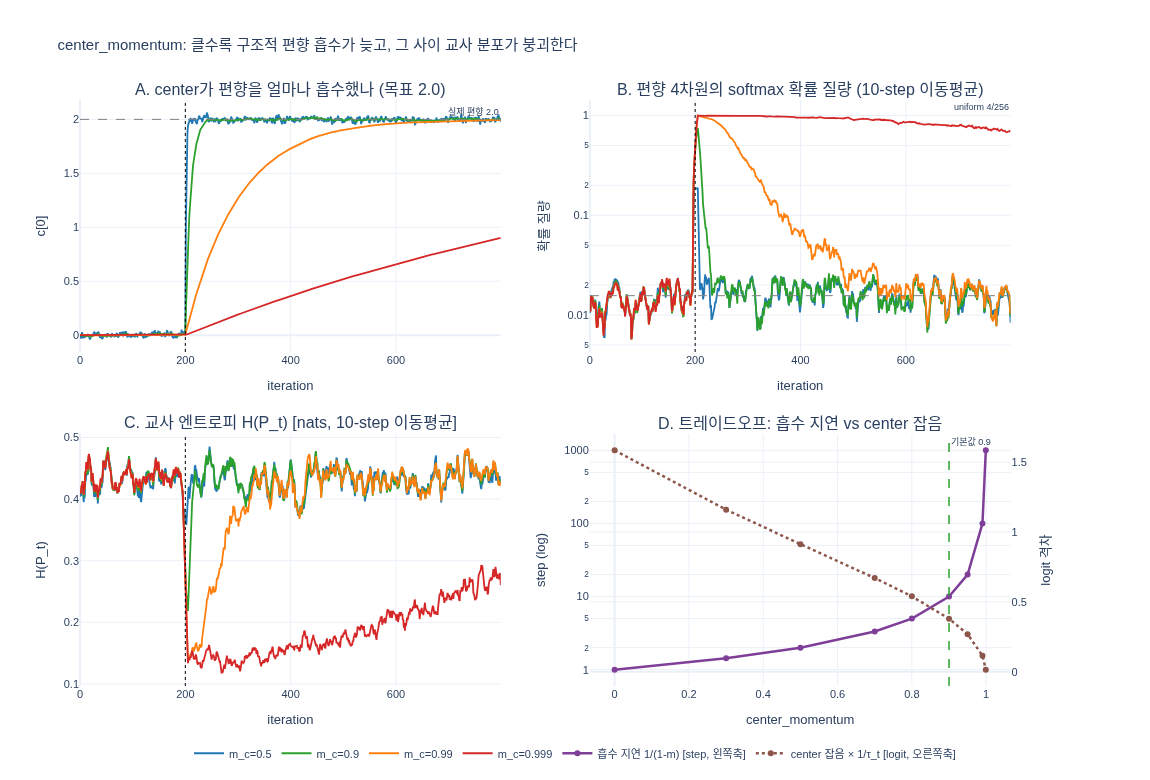

expy.png 저장 완료


In [7]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "A. center가 편향을 얼마나 흡수했나 (목표 2.0)",
        "B. 편향 4차원의 softmax 확률 질량 (10-step 이동평균)",
        "C. 교사 엔트로피 H(P_t) [nats, 10-step 이동평균]",
        "D. 트레이드오프: 흡수 지연 vs center 잡음",
    ),
    specs=[[{}, {}], [{}, {"secondary_y": True}]],
    vertical_spacing=0.14, horizontal_spacing=0.09,
)

COLORS = {0.5: "#1f77b4", 0.9: "#2ca02c", 0.99: "#ff7f0e", 0.999: "#d62728"}
x = np.arange(STEPS)


def smooth(y, w=10):
    """step 단위 표집 잡음을 눌러 추세만 보이게 (질량/엔트로피 패널용)."""
    k = np.ones(w) / w
    return np.convolve(y, k, mode="same") / np.convolve(np.ones_like(y), k, mode="same")


for m, h in runs.items():
    c, nm = COLORS[m], f"m_c={m}"
    fig.add_trace(go.Scatter(x=x, y=h["c0"], name=nm, legendgroup=nm,
                             line=dict(color=c, width=1.8)), row=1, col=1)
    fig.add_trace(go.Scatter(x=x, y=smooth(h["mass"]), name=nm, legendgroup=nm, showlegend=False,
                             line=dict(color=c, width=1.8)), row=1, col=2)
    fig.add_trace(go.Scatter(x=x, y=smooth(h["ent"]), name=nm, legendgroup=nm, showlegend=False,
                             line=dict(color=c, width=1.8)), row=2, col=1)

# 참조선
fig.add_hline(y=BIAS, line=dict(color="gray", dash="dash", width=1), row=1, col=1,
              annotation_text="실제 편향 2.0", annotation_font_size=9)
fig.add_hline(y=UNIFORM, line=dict(color="gray", dash="dash", width=1), row=1, col=2,
              annotation_text="uniform 4/256", annotation_font_size=9)
for r, c_ in [(1, 1), (1, 2), (2, 1)]:
    fig.add_vline(x=ONSET, line=dict(color="black", dash="dot", width=1), row=r, col=c_)

# 패널 D: 지연 vs 잡음
fig.add_trace(go.Scatter(x=M_GRID, y=lag_theo, name="흡수 지연 1/(1-m) [step, 왼쪽축]",
                         line=dict(color="#7f3f98", width=2.5), mode="lines+markers"),
              row=2, col=2, secondary_y=False)
fig.add_trace(go.Scatter(x=M_GRID, y=[n * 25 for n in noise_meas],
                         name="center 잡음 × 1/τ_t [logit, 오른쪽축]",
                         line=dict(color="#8c564b", width=2.5, dash="dot"), mode="lines+markers"),
              row=2, col=2, secondary_y=True)
fig.add_vline(x=0.9, line=dict(color="#2ca02c", dash="dash", width=1.5), row=2, col=2,
              annotation_text="기본값 0.9", annotation_font_size=9)

fig.update_xaxes(title_text="iteration", row=1, col=1)
fig.update_xaxes(title_text="iteration", row=1, col=2)
fig.update_xaxes(title_text="iteration", row=2, col=1)
fig.update_xaxes(title_text="center_momentum", row=2, col=2)
fig.update_yaxes(title_text="c[0]", row=1, col=1)
fig.update_yaxes(title_text="확률 질량", type="log", row=1, col=2)
fig.update_yaxes(title_text="H(P_t)", row=2, col=1)
fig.update_yaxes(title_text="step (log)", type="log", row=2, col=2, secondary_y=False)
fig.update_yaxes(title_text="logit 격차", row=2, col=2, secondary_y=True)
fig.update_layout(
    height=780, width=1150, template="plotly_white",
    title_text="center_momentum: 클수록 구조적 편향 흡수가 늦고, 그 사이 교사 분포가 붕괴한다",
    legend=dict(orientation="h", y=-0.09, x=0.5, xanchor="center"),
    font=dict(size=11),
)

_show(fig)
fig.write_image("expy.png", scale=2)
print("expy.png 저장 완료")

## 정리

| | 증상 | 원인 |
|---|---|---|
| $m_c$ 과다 (0.99, 0.999) | 편향 차원이 확률 질량 독식, $H(P_t)\to$ 낮음, $\lVert c\rVert$ 정체 | EMA 시간상수 $1/(1-m_c)$ 가 편향 드리프트보다 느림 → centering 무력화 |
| $m_c$ 과소 (≈0) | 교사 타겟이 배치마다 요동 | center가 배치 표집 잡음을 그대로 물음, $\tau_t$ 로 25배 증폭 |
| $m_c = 0.9$ | 질량이 uniform 근처 유지, 엔트로피 안정 | 시간상수 10 step — 잡음은 평균 내고 편향은 놓치지 않음 |

실제 학습에서는 여기에 **자기강화 루프**가 더 붙는다. 편향 차원이 교사 타겟을 독식하면
cross-entropy가 학생을 그쪽으로 밀고, EMA 교사가 학생을 따라가 편향이 더 커진다.
즉 center가 따라잡으려는 목표 자체가 도망가므로, 지연은 "늦은 정상화"가 아니라
"그 사이에 붕괴가 자리를 잡음"으로 끝날 수 있다.

그리고 $H(P_t,P_s) = H(P_t) + D_{\mathrm{KL}}(P_t\Vert P_s)$ 이므로 이 붕괴는 **loss를 더 잘 낮춘다**.
DINO 사전학습에는 검증이 없으니 loss 곡선만 보면 이걸 "학습이 잘 된다"로 오독한다.
봐야 하는 건 $H(P_t)$, top-1 확률, argmax 다양성, $\lVert c \rVert_2$ 다.